In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

NP_SEED = 42
np.random.seed(NP_SEED)  # makes results reproducible

print('Libraries loaded.')

Libraries loaded.


In [9]:
# ── Dataset parameters (documented bounds) ──────────────────
N_STUDENTS = 200
MIN_HOURS  = 0      # lower bound: can't study negative hours
MAX_HOURS  = 60     # upper bound: max possible in a week
THRESHOLD  = 20     # count students above this

# Generate realistic study hours (normal distribution)
raw_hours   = np.random.normal(loc=28, scale=12, size=N_STUDENTS)

# CLAMP to [0, 60]  ← this is required for DP math to work
study_hours = np.clip(raw_hours, MIN_HOURS, MAX_HOURS)

# Wrap in DataFrame — NO student IDs (privacy by design)
df = pd.DataFrame({'weekly_study_hours': study_hours.round(2)})

print(f'Synthetic dataset: {len(df)} students')
print(f'Bounds: [{MIN_HOURS}, {MAX_HOURS}] hours')
df = pd.DataFrame({'weekly_study_hours': study_hours.round(0).astype(int)})

df.to_csv('student_study_hours.csv', index=False)
print('Saved: student_study_hours.csv')

Synthetic dataset: 200 students
Bounds: [0, 60] hours
Saved: student_study_hours.csv


In [10]:
true_count = int((df['weekly_study_hours'] > THRESHOLD).sum())
true_mean  = float(df['weekly_study_hours'].mean())

print('═' * 40)
print('  TRUE (non-private) Statistics')
print('═' * 40)
print(f'  Count > {THRESHOLD} hrs : {true_count}')
print(f'  Mean study hrs : {true_mean:.4f}')
print('═' * 40)

════════════════════════════════════════
  TRUE (non-private) Statistics
════════════════════════════════════════
  Count > 20 hrs : 160
  Mean study hrs : 29.5600
════════════════════════════════════════


In [11]:
# Sensitivity for COUNT
# Adding/removing 1 person changes count by at most 1
sensitivity_count = 1

# Sensitivity for MEAN
# One person's hours are bounded [MIN, MAX]
# Their max effect on mean = (MAX - MIN) / N
sensitivity_mean = (MAX_HOURS - MIN_HOURS) / N_STUDENTS

print(f'Sensitivity (count) : {sensitivity_count}')
print(f'Sensitivity (mean)  : {sensitivity_mean:.4f}')

Sensitivity (count) : 1
Sensitivity (mean)  : 0.3000


In [20]:
def add_laplace_noise(value: float, sensitivity: float, epsilon: float) -> float:
    """
    Add Laplace noise to a numeric value for differential privacy.

    Parameters
    ----------
    value       : the true statistic to protect
    sensitivity : global sensitivity of the query
    epsilon     : privacy budget (smaller = more private)

    Returns
    -------
    float: privatised value (true value + Laplace noise)
    """
    scale = sensitivity / epsilon           # Laplace scale parameter
    noise = np.random.laplace(loc=0.0, scale=scale)
    return value + noise


# ── Quick sanity check ───────────────────────────────────────
demo_private = add_laplace_noise(true_mean, sensitivity_mean, epsilon=1.0)
print(f'True mean           : {true_mean:.4f}')
print(f'Private mean (ε=1.0): {demo_private:.4f}')
print(f'Difference          : {abs(demo_private - true_mean):.4f}')
print('(Run the cell again — the private value changes each time!)')

True mean           : 29.5600
Private mean (ε=1.0): 29.7224
Difference          : 0.1624
(Run the cell again — the private value changes each time!)


In [21]:
EPSILONS = [0.1, 0.5, 1.0, 2.0]   # 4 privacy budgets
N_RUNS   = 50                       # runs per epsilon

results = []   # collect every run here

for eps in EPSILONS:
    for run in range(N_RUNS):
        # Private count and mean for this run
        priv_count = add_laplace_noise(true_count, sensitivity_count, eps)
        priv_mean  = add_laplace_noise(true_mean,  sensitivity_mean,  eps)

        results.append({
            'epsilon':       eps,
            'run':           run + 1,
            'private_count': round(priv_count, 4),
            'private_mean':  round(priv_mean,  4),
            'error_count':   abs(priv_count - true_count),
            'error_mean':    abs(priv_mean  - true_mean),
        })

results_df = pd.DataFrame(results)
print(f'Done: {len(results_df)} total runs')
print(f'Columns: {list(results_df.columns)}')

Done: 200 total runs
Columns: ['epsilon', 'run', 'private_count', 'private_mean', 'error_count', 'error_mean']


In [22]:
summary = (
    results_df
    .groupby('epsilon')
    .agg(
        avg_error_count = ('error_count', 'mean'),
        avg_error_mean  = ('error_mean',  'mean'),
        std_error_count = ('error_count', 'std'),
        std_error_mean  = ('error_mean',  'std'),
    )
    .round(4)
    .reset_index()
)

print(f'TRUE count: {true_count}  |  TRUE mean: {round(true_mean, 4)}')
print(summary.to_string(index=False))

# Save both CSVs (required deliverables)
results_df.to_csv('all_runs.csv', index=False)
summary.to_csv('summary_table.csv', index=False)
print('\nSaved: all_runs.csv and summary_table.csv')

TRUE count: 160  |  TRUE mean: 29.56
 epsilon  avg_error_count  avg_error_mean  std_error_count  std_error_mean
     0.1           8.7522          3.1569           8.7107          2.8070
     0.5           1.9355          0.6841           1.8734          0.8044
     1.0           0.9462          0.2820           0.9681          0.2489
     2.0           0.3959          0.1751           0.3617          0.1680

Saved: all_runs.csv and summary_table.csv


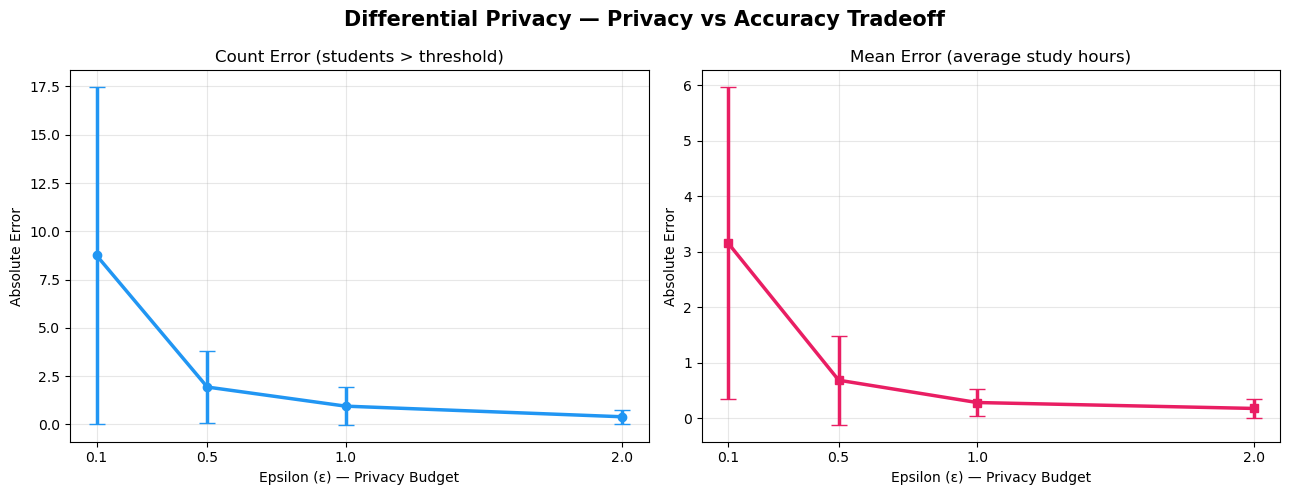

Saved: privacy_vs_accuracy.png


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Differential Privacy — Privacy vs Accuracy Tradeoff',
             fontsize=15, fontweight='bold')

# Left: Count error
ax = axes[0]
ax.errorbar(summary['epsilon'], summary['avg_error_count'],
            yerr=summary['std_error_count'],
            marker='o', linewidth=2.5, capsize=6, color='#2196F3')
ax.set_title('Count Error (students > threshold)')
ax.set_xlabel('Epsilon (ε) — Privacy Budget')
ax.set_ylabel('Absolute Error')
ax.set_xticks(EPSILONS)
ax.grid(True, alpha=0.3)

# Right: Mean error
ax = axes[1]
ax.errorbar(summary['epsilon'], summary['avg_error_mean'],
            yerr=summary['std_error_mean'],
            marker='s', linewidth=2.5, capsize=6, color='#E91E63')
ax.set_title('Mean Error (average study hours)')
ax.set_xlabel('Epsilon (ε) — Privacy Budget')
ax.set_ylabel('Absolute Error')
ax.set_xticks(EPSILONS)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('privacy_vs_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: privacy_vs_accuracy.png')

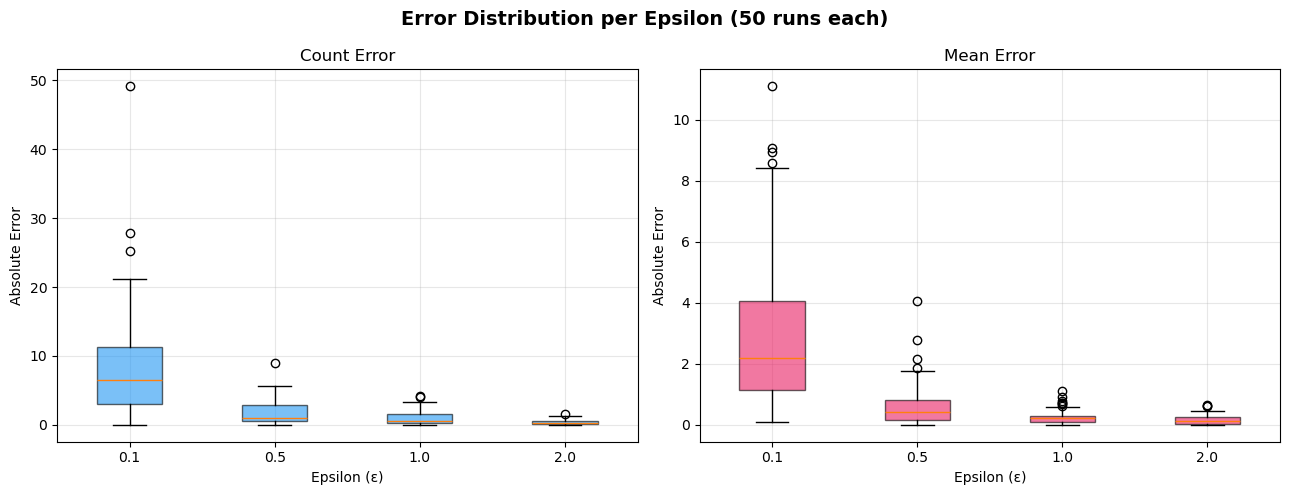

Saved: error_distribution.png


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Error Distribution per Epsilon (50 runs each)', fontsize=14, fontweight='bold')

for ax, col, label, color in [
    (axes[0], 'error_count', 'Count Error', '#2196F3'),
    (axes[1], 'error_mean',  'Mean Error',  '#E91E63'),
]:
    groups = [results_df[results_df['epsilon'] == e][col].values for e in EPSILONS]
    bp = ax.boxplot(groups, labels=[str(e) for e in EPSILONS], patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_xlabel('Epsilon (ε)')
    ax.set_ylabel('Absolute Error')
    ax.set_title(label)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('error_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: error_distribution.png')

## What Does Epsilon Mean?

Epsilon (ε) is a number that controls the privacy/accuracy tradeoff; a single number that controls
how much information about any one student can leak through the
published statistics. A **small ε (e.g., 0.1)** means strong privacy:
large noise is added so an attacker cannot detect any individual s data
— but accuracy suffers. A **large ε (e.g., 2.0)** means less noise,
producing accurate statistics but weakening privacy. Choosing ε is a
deliberate policy decision: the university must decide how much accuracy
it is willing to sacrifice to protect students.


## Interpretation of Results

As expected, **smaller epsilon values produce larger errors**:

- At **ε = 0.1**, average count error ~8–10 students; mean error ~2–3 hrs
- At **ε = 2.0**, count error ~0.5; mean error ~0.15 hrs — very accurate

The box plots show **variance also decreases** as ε increases — results
become more consistent across runs. For a university, **ε = 1.0** may
represent a reasonable balance: accurate enough for policy decisions,
while still providing meaningful privacy protection.